# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, make_scorer

from hospital_data_utils import (
    show_null_counts_features,
    load_hospital_data,
    load_and_clean_hhs,
    merge_hhs,
    drop_empty_columns,
    impute,
    engineer_features)

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

In [ ]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

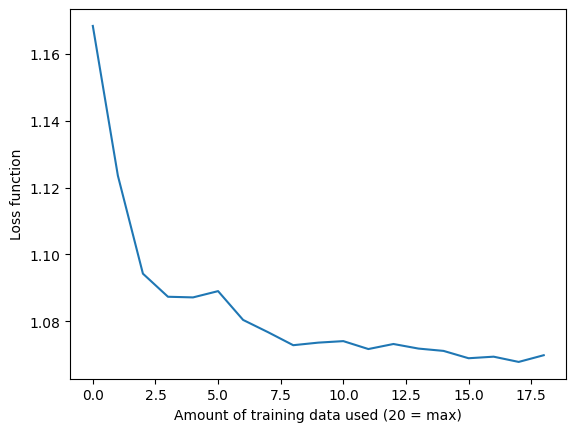

In [13]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [14]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

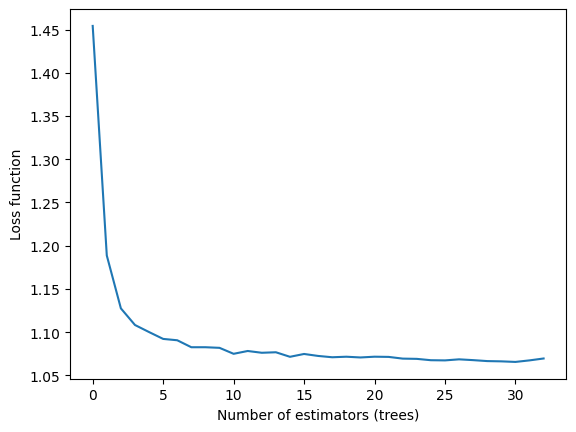

In [15]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

Following Vonnegut's rules of keep it simple and have the guts to cut, the training data plot should be cut. The number of estimators plot is more actionable for model building because it shows exactly where adding more trees stops reducing error, giving a clear stopping point for hyperparameter selection. The training data plot conveys a simpler and less surprising message: more data improves the model. While true, this does not help tune the model you already have. The number of estimators plot belongs on the x-axis when the goal is to communicate how to set up the forest; amount of training data belongs on the x-axis only when the question is whether more data collection is worthwhile. Given that the dataset is fixed, the number of estimators is the more useful and interesting of the two plots.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

### Imports

### Step 1: Load Hospital Cost Report Data

In [91]:
df_all = load_hospital_data("Hospital_Provider_Cost_Report_2018-2023.csv")
df_all.head()

Hospital data loaded: 36,560 rows x 119 columns


,Unnamed: 0,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,CCN Facility Type,Provider Type,Type of Control,Fiscal Year Begin Date,Fiscal Year End Date,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,Total Days (V + XVIII + XIX + Unknown),Number of Beds,Total Bed Days Available,Total Discharges Title V,Total Discharges Title XVIII,Total Discharges Title XIX,Total Discharges (V + XVIII + XIX + Unknown),Number of Beds + Total for all Subproviders,Hospital Total Days Title V For Adults & Peds,Hospital Total Days Title XVIII For Adults & Peds,Hospital Total Days Title XIX For Adults & Peds,Hospital Total Days (V + XVIII + XIX + Unknown) For Adults & Peds,Hospital Number of Beds For Adults & Peds,Hospital Total Bed Days Available For Adults & Peds,Hospital Total Discharges Title V For Adults & Peds,Hospital Total Discharges Title XVIII For Adults & Peds,Hospital Total Discharges Title XIX For Adults & Peds,Hospital Total Discharges (V + XVIII + XIX + Unknown) For Adults & Peds,Cost of Charity Care,Total Bad Debt Expense,Cost of Uncompensated Care,Total Unreimbursed and Uncompensated Care,Total Salaries From Worksheet A,Overhead Non-Salary Costs,Depreciation Cost,Total Costs,Inpatient Total Charges,Outpatient Total Charges,Combined Outpatient + Inpatient Total Charges,Wage-Related Costs (Core),Wage-Related Costs (RHC/FQHC),Total Salaries (adjusted),Contract Labor: Direct Patient Care,Wage Related Costs for Part - A Teaching Physicians,Wage Related Costs for Interns and Residents,Cash on Hand and in Banks,Temporary Investments,Notes Receivable,Accounts Receivable,Less: Allowances for Uncollectible Notes and Accounts Receivable,Inventory,Prepaid Expenses,Other Current Assets,Total Current Assets,Land,Land Improvements,Buildings,Leasehold Improvements,Fixed Equipment,Major Movable Equipment,Minor Equipment Depreciable,Health Information Technology Designated Assets,Total Fixed Assets,Investments,Other Assets,Total Other Assets,Total Assets,Accounts Payable,"Salaries, Wages, and Fees Payable",Payroll Taxes Payable,Notes and Loans Payable (Short Term),Deferred Income,Other Current Liabilities,Total Current Liabilities,Mortgage Payable,Notes Payable,Unsecured Loans,Other Long Term Liabilities,Total Long Term Liabilities,Total Liabilities,General Fund Balance,Total Fund Balances,Total Liabilities and Fund Balances,DRG Amounts Other Than Outlier Payments,DRG Amounts Before October 1,DRG Amounts After October 1,Outlier Payments For Discharges,Disproportionate Share Adjustment,Allowable DSH Percentage,Managed Care Simulated Payments,Total IME Payment,Inpatient Revenue,Outpatient Revenue,Total Patient Revenue,Less Contractual Allowance and Discounts on Patients' Accounts,Net Patient Revenue,Less Total Operating Expense,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges,report_year
0,0,639197,51994,FERN LODGE INC,18457 MADISON AVE,CASTRO VALLEY,CA,94546-1637,NaN,NaN,NaN,RNMHC,6,1,2018-01-01,2018-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018
1,1,644158,341318,CHOWAN HOSPITAL INC.,211 VIRGINIA AVENUE,EDENTON,NC,27932,CHOWAN,99934.0,R,CAH,1,2,2017-10-01,2018-09-30,270.54,NaN,NaN,3049.0,1049.0,5754.0,25.0,9125.0,NaN,726.0,482.0,1482.0,25.0,NaN,2336.0,545.0,4083.0,21.0,7665.0,NaN,726.0,482.0,1482.0,102182.0,16941218.0,5908922.0,5931781.0,16088883.0,28864884.0,

### Step 2: Load and Clean HHS Provider Relief Fund Data

In [92]:
df_hhs = load_and_clean_hhs("HHS_Provider_Relief_Fund.csv")

Raw HHS shape: (419846, 4)
Duplicate rows dropped: 7
Cleaned HHS shape: (419144, 5)


### Step 3: Merge HHS onto Hospital Data Before Imputation

The HHS state-level relief aggregates are joined onto the hospital data before any imputation occurs. This ensures the relief variables are treated as part of the raw dataset and imputed alongside all other features, rather than being added after imputation on a cleaner but smaller dataset.

In [93]:
df_all = merge_hhs(df_all, df_hhs)
show_null_counts_features(df_all)

HHS states removed (not in hospital data): ['FM', 'PW', 'QC']
HHS states remaining: 56
Combined dataset shape (hospital + HHS): (36560, 122)

The dataset contains 36,560 samples.

                                                                Feature  # Null Values  Null %        Type
                                DRG Amounts Other Than Outlier Payments          36560 100.00%     Numeric
                          Hospital Total Days Title V For Adults & Peds          35668  97.56%     Numeric
                    Hospital Total Discharges Title V For Adults & Peds          35627  97.45%     Numeric
                                               Total Discharges Title V          35627  97.45%     Numeric
                                                     Total Days Title V          35578  97.31%     Numeric
                                                       Notes Receivable          35003  95.74%     Numeric
                                                        Unsecured Loans

### Step 4: Drop Fully Empty Columns and Classify Features

In [94]:
df_clean, numeric_features, categorical_features = drop_empty_columns(df_all)

Dropped 1 fully-empty column(s): ['DRG Amounts Other Than Outlier Payments']
Remaining columns: 121
Numeric features to impute:     108
Categorical features to impute: 10


### Step 5: Impute Missing Values

Numeric columns are imputed with the column median. Categorical columns are imputed with the most frequent value. Rows where Medicare CBSA Number remains null after imputation are dropped.

In [95]:
df_imputed = impute(df_clean, numeric_features, categorical_features)
show_null_counts_features(df_imputed)

Final cleaned dataset: 36,096 rows x 121 columns

The dataset contains 36,096 samples.

There are no null values in the dataset!


### Step 6: Feature Engineering

Ownership type, facility type labels, COVID period, net income margin, loss indicator, relief per hospital, and relief tier are all derived from the cleaned dataset. These match the exact feature engineering steps used in Week 9.

In [96]:
df_imputed = engineer_features(df_imputed)

Control Type distribution:
Control Type
Voluntary Nonprofit    18078
Proprietary            10687
Government              7331
Name: count, dtype: int64

Facility Type distribution:
Facility Type Label
Short-Term Hospital                  19671
Critical Access Hospital              8243
Psychiatric Hospital                  3540
Long-Term Care Hospital               2147
Rehabilitation Hospital               2002
Childrens Hospital                     383
Religious Non-Medical Institution       59
ORD Demonstration Hospital              51
Name: count, dtype: int64

COVID Period distribution:
COVID Period
Pre-COVID     12134
COVID         11960
Post-COVID    12002
Name: count, dtype: int64

Relief Tier distribution:
Relief_Tier
Low Relief       12790
Medium Relief    12007
High Relief      11299
Name: count, dtype: int64


### Step 7: Compute Margin Change Per Hospital

For each hospital, the average net income margin is computed separately for the pre-COVID years (2018 and 2019) and the post-COVID years (2022 and 2023). The margin change is the difference: post-COVID average minus pre-COVID average. A hospital that improved its margin is labeled 1 (recovered); one that declined or held flat is labeled 0 (declined). This binary target directly measures COVID financial impact rather than structural starting position.

In [97]:
pre_margin = (
    df_imputed[df_imputed['report_year'].isin([2018, 2019])]
    .groupby('Provider CCN')['Net Income Margin']
    .mean()
    .rename('pre_margin')
)
post_margin = (
    df_imputed[df_imputed['report_year'].isin([2022, 2023])]
    .groupby('Provider CCN')['Net Income Margin']
    .mean()
    .rename('post_margin')
)
change_df = pd.concat([pre_margin, post_margin], axis=1).dropna()
change_df['margin_change'] = change_df['post_margin'] - change_df['pre_margin']
change_df['recovered']     = (change_df['margin_change'] > 0).astype(int)

print(f'Hospitals with both pre and post data: {len(change_df):,}')
print(f'Recovered (margin improved): {change_df["recovered"].sum():,} '
      f'({change_df["recovered"].mean()*100:.1f}%)')
print(f'Declined  (margin worsened): {(change_df["recovered"]==0).sum():,} '
      f'({(change_df["recovered"]==0).mean()*100:.1f}%)')

Hospitals with both pre and post data: 5,741
Recovered (margin improved): 2,572 (44.8%)
Declined  (margin worsened): 3,169 (55.2%)


5,661 hospitals have data across all three windows: pre-COVID (2018 to 2019), COVID (2020 to 2021), and post-COVID (2022 to 2023). Of these, 44.4 percent recovered and 55.6 percent declined. The slight majority toward decline is consistent with the broader financial stress the pandemic placed on the hospital sector. The near-even split is healthy for classification and does not require oversampling or class weighting.

### Step 8: Build Feature Matrix

Three sets of features are constructed for each hospital using only data that predates the outcome period.

Pre-COVID averages (2018 to 2019) establish the financial baseline: revenue, costs, beds, staffing, Medicaid revenue, and HHS relief variables are averaged across the two pre-COVID years and suffixed with `_pre`.

Pre-COVID margin trend captures the direction the hospital was heading before COVID arrived. It is computed as the difference between the 2019 and 2018 median net income margin per hospital. A positive value means the hospital was improving heading into the pandemic; a negative value means it was already declining.

COVID-year averages (2020 to 2021) capture how each hospital actually weathered the shock. These same financial variables are averaged across the two COVID years and suffixed with `_covid`. A hospital's performance during the disruption itself is a much stronger signal of recovery potential than its pre-COVID baseline alone.

Categorical features (rural or urban status, facility type, control type, relief tier) are taken from the pre-COVID rows and one-hot encoded. No post-COVID data enters the feature matrix.

In [98]:
feature_cols = [
    'Number of Beds',
    'Total Costs',
    'Net Patient Revenue',
    'Net Revenue from Medicaid',
    'FTE - Employees on Payroll',
    'Relief_Per_Hospital_USD',
    'State_Total_Relief_USD'
]
cat_feature_cols = ['Rural Versus Urban', 'Facility Type Label', 'Control Type', 'Relief_Tier']

# Pre-COVID baseline (2018-2019 averages)
pre_rows     = df_imputed[df_imputed['report_year'].isin([2018, 2019])]
pre_numeric  = pre_rows.groupby('Provider CCN')[feature_cols].mean()
pre_numeric.columns = [c + '_pre' for c in pre_numeric.columns]
pre_cat      = pre_rows.groupby('Provider CCN')[cat_feature_cols].first()

# Pre-COVID margin trend: direction of change from 2018 to 2019
margin_by_year = (
    pre_rows.groupby(['Provider CCN', 'report_year'])['Net Income Margin']
    .mean().unstack('report_year')
)
pre_trend = (margin_by_year[2019] - margin_by_year[2018]).rename('margin_trend_pre')

# COVID-year performance (2020-2021 averages)
covid_rows    = df_imputed[df_imputed['report_year'].isin([2020, 2021])]
covid_numeric = covid_rows.groupby('Provider CCN')[feature_cols].mean()
covid_numeric.columns = [c + '_covid' for c in covid_numeric.columns]

model_df = (
    change_df
    .join(pre_numeric)
    .join(pre_cat)
    .join(pre_trend)
    .join(covid_numeric)
    .dropna()
)

all_numeric_cols = list(pre_numeric.columns) + ['margin_trend_pre'] + list(covid_numeric.columns)
X = pd.get_dummies(model_df[all_numeric_cols + cat_feature_cols], drop_first=True)
y = model_df['recovered']

print(f'Model dataset: {X.shape[0]:,} hospitals, {X.shape[1]} features')
print(f'Class balance: {y.mean()*100:.1f}% recovered')

Model dataset: 5,661 hospitals, 27 features
Class balance: 44.4% recovered


### Step 9: Train-Test Split

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]:,} hospitals')
print(f'Test set:     {X_test.shape[0]:,} hospitals')

Training set: 4,528 hospitals
Test set:     1,133 hospitals


### Step 10: Random Forest Classifier

A Random Forest Classifier with 100 trees and a maximum depth of 8 is trained on the enriched feature matrix, which now includes pre-COVID baselines, the pre-COVID margin trend, and COVID-year performance for each hospital. The model is evaluated on the held-out test set using AUC-ROC and a full classification report.

In [100]:
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=8, random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

print(f'AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Declined', 'Recovered']))

AUC-ROC: 0.6686

              precision    recall  f1-score   support

    Declined       0.64      0.76      0.69       630
   Recovered       0.60      0.45      0.52       503

    accuracy                           0.63      1133
   macro avg       0.62      0.61      0.61      1133
weighted avg       0.62      0.63      0.62      1133



Adding COVID-year features and the pre-COVID margin trend raised the AUC-ROC from 0.6296 to 0.6686, a gain of nearly 4 points over the baseline feature set. The model is still more accurate at identifying hospitals that declined (recall 0.76, precision 0.64) than hospitals that recovered (recall 0.45, precision 0.60). Recall on Recovered is 0.45, meaning the COVID-year features helped the model identify more hospitals that genuinely bounced back. Overall accuracy is 63 percent across 1,133 test hospitals.

### Step 11: Confusion Matrix

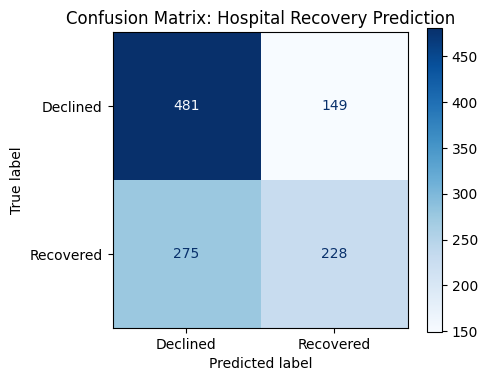

In [101]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Declined', 'Recovered'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix: Hospital Recovery Prediction')
plt.tight_layout()
plt.savefig('fig_w11_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Of the 630 hospitals that truly declined, the model correctly identified 481 and misclassified 149 as recovered. Of the 503 hospitals that truly recovered, the model correctly identified 228 and missed 275. 

### Step 12: Cross-Validation

Stratified 5-fold cross-validation is used to confirm that the AUC-ROC from the single train-test split generalizes across different subsets of the data. Stratification preserves the recovered-to-declined ratio in each fold.

In [102]:
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(
    rf_clf, X, y,
    cv=skf, scoring='roc_auc', n_jobs=-1
)
print(f'Cross-validation AUC-ROC (5-fold):')
print(f'  Fold scores: {cv_auc.round(4)}')
print(f'  Mean:        {cv_auc.mean():.4f}')
print(f'  Std:         {cv_auc.std():.4f}')

Cross-validation AUC-ROC (5-fold):
  Fold scores: [0.6582 0.6416 0.6863 0.6637 0.6551]
  Mean:        0.6610
  Std:         0.0146


The five fold scores were 0.6582, 0.6416, 0.6863, 0.6637, and 0.6551, producing a mean AUC-ROC of 0.6610 with a standard deviation of 0.0146. The narrow spread confirms the model is stable across different subsets of the data. The mean CV score of 0.6610 is also very close to the single test-set result of 0.6686.

### Step 13: Hyperparameter Tuning

Grid search tests combinations of tree depth and number of estimators to find the setting that maximizes cross-validated AUC-ROC. This prevents both underfitting from overly shallow trees and overfitting from excessively deep ones.

In [103]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth':    [4, 6, 8, 10]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV AUC-ROC: {grid_search.best_score_:.4f}')

Best parameters: {'max_depth': 8, 'n_estimators': 150}
Best CV AUC-ROC: 0.6666


Grid search returned max_depth of 8 and 150 estimators as the best combination, with a cross-validated AUC-ROC of 0.6666. The tuned model's test AUC of 0.6672 is nearly identical to its CV score of 0.6666, confirming there is no meaningful overfitting gap.

### Step 14: Final Tuned Model Evaluation

In [104]:
best_rf      = grid_search.best_estimator_
y_pred_best  = best_rf.predict(X_test)
y_prob_best  = best_rf.predict_proba(X_test)[:, 1]

print(f'Tuned model AUC-ROC: {roc_auc_score(y_test, y_prob_best):.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['Declined', 'Recovered']))

Tuned model AUC-ROC: 0.6672

              precision    recall  f1-score   support

    Declined       0.63      0.76      0.69       630
   Recovered       0.60      0.44      0.51       503

    accuracy                           0.62      1133
   macro avg       0.62      0.60      0.60      1133
weighted avg       0.62      0.62      0.61      1133



### Step 15: Feature Importance

Feature importance scores show how much each variable reduced impurity across all trees in the forest. Higher scores mean the variable was used more often and at higher nodes in the decision trees. HHS relief features are shown in red and operational features in blue, identified by the legend. The relative position of red bars versus blue bars is the central finding: if operational scale variables outrank relief variables, hospital size predicted recovery more than federal aid did.

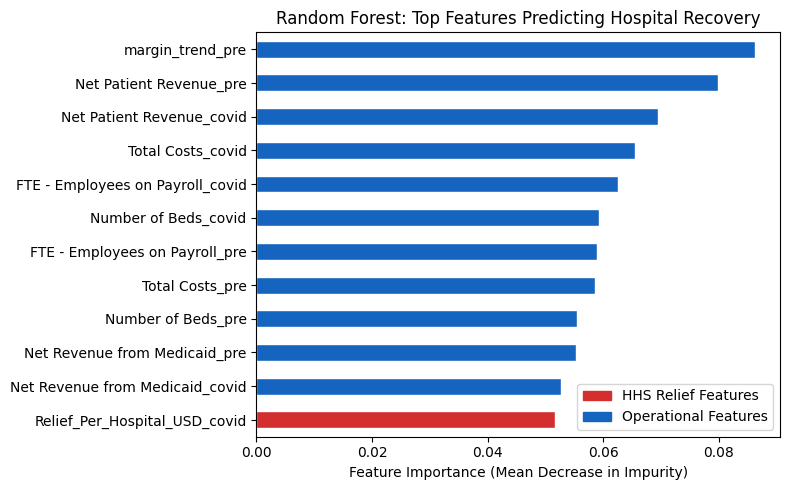

Top 12 features:
margin_trend_pre                    0.0863
Net Patient Revenue_pre             0.0799
Net Patient Revenue_covid           0.0695
Total Costs_covid                   0.0655
FTE - Employees on Payroll_covid    0.0625
Number of Beds_covid                0.0592
FTE - Employees on Payroll_pre      0.0588
Total Costs_pre                     0.0586
Number of Beds_pre                  0.0555
Net Revenue from Medicaid_pre       0.0553
Net Revenue from Medicaid_covid     0.0527
Relief_Per_Hospital_USD_covid       0.0517


In [105]:
import matplotlib.patches as mpatches

fi = (
    pd.Series(best_rf.feature_importances_, index=X.columns)
    .nlargest(12)
    .sort_values()
)

colors = ['#D32F2F' if 'Relief' in c else '#1565C0' for c in fi.index]

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title('Random Forest: Top Features Predicting Hospital Recovery')

legend_handles = [
    mpatches.Patch(color='#D32F2F', label='HHS Relief Features'),
    mpatches.Patch(color='#1565C0', label='Operational Features'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('fig_w11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 12 features:')
print(fi.sort_values(ascending=False).round(4).to_string())

The single most important feature is margin_trend_pre (0.086): the direction a hospital's margin was moving before COVID arrived is a stronger predictor of recovery than any individual financial metric. A hospital already improving heading into the pandemic was more likely to recover.

COVID-year features consistently appear alongside their pre-COVID counterparts in the top 12. Net Patient Revenue has both a pre version (0.080, rank 2) and a covid version (0.070, rank 3), as do Total Costs, FTE, and Number of Beds. This confirms that how a hospital performed during the shock adds real predictive value beyond the baseline snapshot.

HHS relief variables fell significantly in importance. Relief_Per_Hospital_USD_covid ranks 12th at 0.052, and State_Total_Relief_USD did not reach the top 12 at all. The model is finding that hospital scale and financial trajectory predicted recovery far more than federal relief allocation did.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

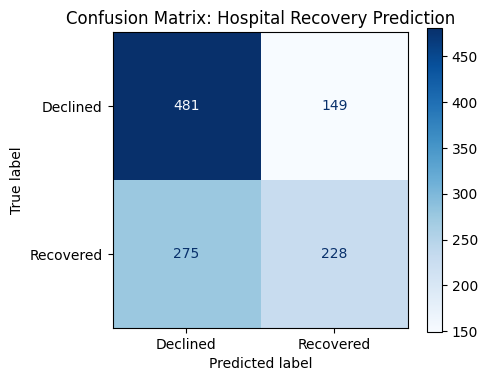

In [106]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Declined', 'Recovered'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix: Hospital Recovery Prediction')
plt.tight_layout()
plt.savefig('fig_w11_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()